In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint


 #1. 忽視警告訊息 (如：FutureWarning 等)
warnings.filterwarnings('ignore')

# 2. 設定繁體中文顯示 (以 Windows 常見字體為例，Mac 使用者可改為 'Arial Unicode MS')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False # 確保負號顯示正常

# 讀取最終版資料
df = pd.read_csv('../data/processed/yrbs_final.csv')
print(f"✅ 資料載入成功，樣本數：{len(df)}")

✅ 資料載入成功，樣本數：12669


2007 年美國高中生中有飲酒習慣（Success）的比例，是否顯著不同於基準值 0.35？

In [32]:
# 1. 計算樣本比例 (Sample Proportion)
n_alc = len(df['alcohol_binary'].dropna())
successes = df['alcohol_binary'].sum()
sample_p = successes / n_alc

# 2. 設定基準值 (Benchmark p0)
p0 = 0.35 #

# 3. 建構 95% 信賴區間 (Confidence Interval)
ci_low_p, ci_high_p = proportion_confint(successes, n_alc, alpha=0.05)

# 4. 執行單一樣本 Z 檢定 (One-sample Z-test)
z_stat, p_val_p = proportions_ztest(successes, n_alc, value=p0)

print(f"樣本比例: {sample_p:.4f}")
print(f"95% CI: [{ci_low_p:.4f}, {ci_high_p:.4f}]")
print(f"P-value: {p_val_p:.4e}")

樣本比例: 0.4517
95% CI: [0.4431, 0.4604]
P-value: 3.8041e-117


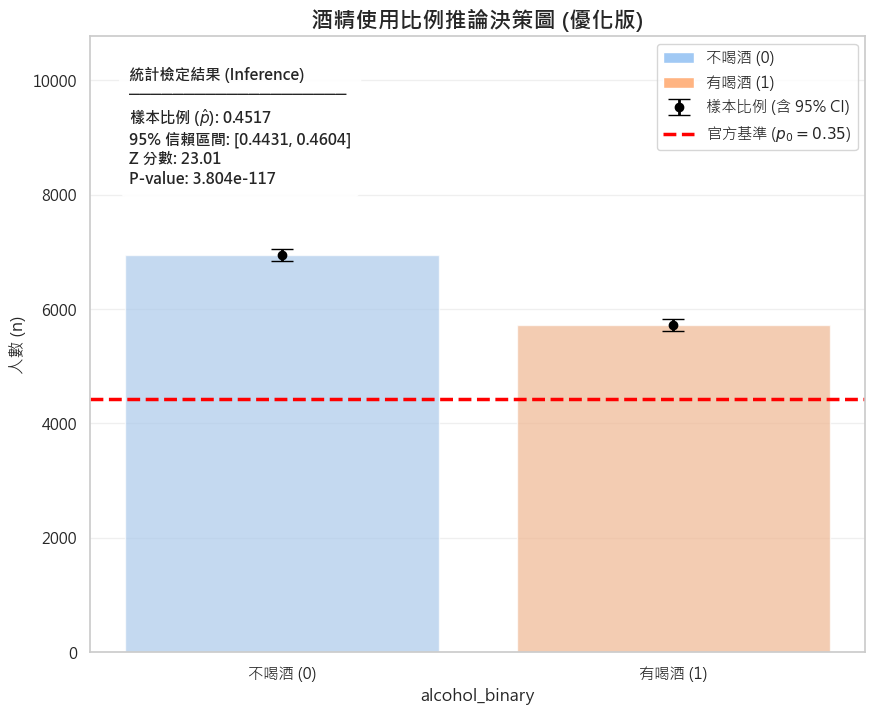

In [33]:
# --- 酒精比例推論視覺化優化版 (雙 CI + 空間拉升) ---

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch

# 1. 準備繪圖數據 (確保變數名稱與你之前的代碼一致)
# successes: 有喝酒人數, n_total: 總有效樣本
fail_count = n_total - successes

# 計算「不喝酒組」的 95% 信賴區間 (反轉比例)
ci_low_fail_y = n_total * (1 - ci_high_p)
ci_high_fail_y = n_total * (1 - ci_low_p)

# 計算「有喝酒組」的信賴區間高度
ci_low_success_y = n_total * ci_low_p
ci_high_success_y = n_total * ci_high_p

# 2. 建立圖表
fig, ax = plt.subplots(figsize=(10, 8))

# (A) 繪製底圖
sns.countplot(x='alcohol_binary', data=df, palette='pastel', hue='alcohol_binary', legend=False, ax=ax, alpha=0.7)


# 不喝酒組 (x=0)
ax.errorbar(x=0, y=fail_count, yerr=[[fail_count - ci_low_fail_y], [ci_high_fail_y - fail_count]], 
            fmt='o', color='black', markersize=6, capsize=8, linewidth=2)
# 有喝酒組 (x=1)
ax.errorbar(x=1, y=successes, yerr=[[successes - ci_low_success_y], [ci_high_success_y - successes]], 
            fmt='o', color='black', markersize=6, capsize=8, linewidth=2, label='樣本比例 (含 95% CI)')

# 取得目前最高長條的高度，並增加 35% 的緩衝空間
max_h = max(fail_count, successes)
ax.set_ylim(0, max_h * 1.55)

# (C) 加入官方基準線 (p0=0.35)
ax.axhline(y=n_total * 0.35, color='red', linestyle='--', linewidth=2.5, label=f'官方基準 ($p_0=0.35$)')

# (D) 標註 P-value 與統計資訊 (位置固定在左上角)
p_text = f"P-value: {p_val_p:.3e}" if p_val_p > 0 else "P-value: < 2.2e-16"
stats_text = (f"統計檢定結果 (Inference)\n"
              f"────────────────────\n"
              f"樣本比例 ($\hat{{p}}$): {sample_p:.4f}\n"
              f"95% 信賴區間: [{ci_low_p:.4f}, {ci_high_p:.4f}]\n"
              f"Z 分數: {z_stat:.2f}\n"
              f"{p_text}")

ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.6'),
        verticalalignment='top', fontweight='bold')

# (E) 細節美化
ax.set_xticks([0, 1])
ax.set_xticklabels(['不喝酒 (0)', '有喝酒 (1)'])
ax.set_title('酒精使用比例推論決策圖 (優化版)', fontsize=16, fontweight='bold')
ax.set_ylabel('人數 (n)', fontsize=12)

# 自定義圖例
handles, labels = ax.get_legend_handles_labels()
legend_elements = [
    Patch(facecolor='#a1c9f4', label='不喝酒 (0)'),
    Patch(facecolor='#ffb482', label='有喝酒 (1)'),
    handles[1], # 基準線
    handles[0]  # 誤差棒
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)

plt.grid(axis='y', alpha=0.3)
plt.savefig('../outputs/figures/03_alcohol_inference_refined_plot.png', dpi=300, bbox_inches='tight')
plt.show()

2007 年美國高中生的平均體重，是否顯著不同於 68.0 公斤？

In [34]:
# 1. 計算樣本統計量 (Size, Mean, SD)
weight_data = df['HowMuchDoYouWeighWithoutShoesInKG'].dropna()
n_w = len(weight_data)
mean_w = weight_data.mean()
sd_w = weight_data.std()

# 2. 設定基準值 (Benchmark mu0)
mu0 = 68.0 #

# 3. 建構 95% 信賴區間 (Confidence Interval)
ci_w = stats.t.interval(0.95, df=n_w-1, loc=mean_w, scale=stats.sem(weight_data))

# 4. 執行單一樣本 t 檢定 (One-sample t-test)
t_stat, p_val_w = stats.ttest_1samp(weight_data, popmean=mu0)

print(f"n={n_w}, Mean={mean_w:.2f}, SD={sd_w:.2f}")
print(f"95% CI: [{ci_w[0]:.2f}, {ci_w[1]:.2f}]")
print(f"P-value: {p_val_w:.4e}")

n=11843, Mean=68.43, SD=16.90
95% CI: [68.12, 68.73]
P-value: 6.0993e-03


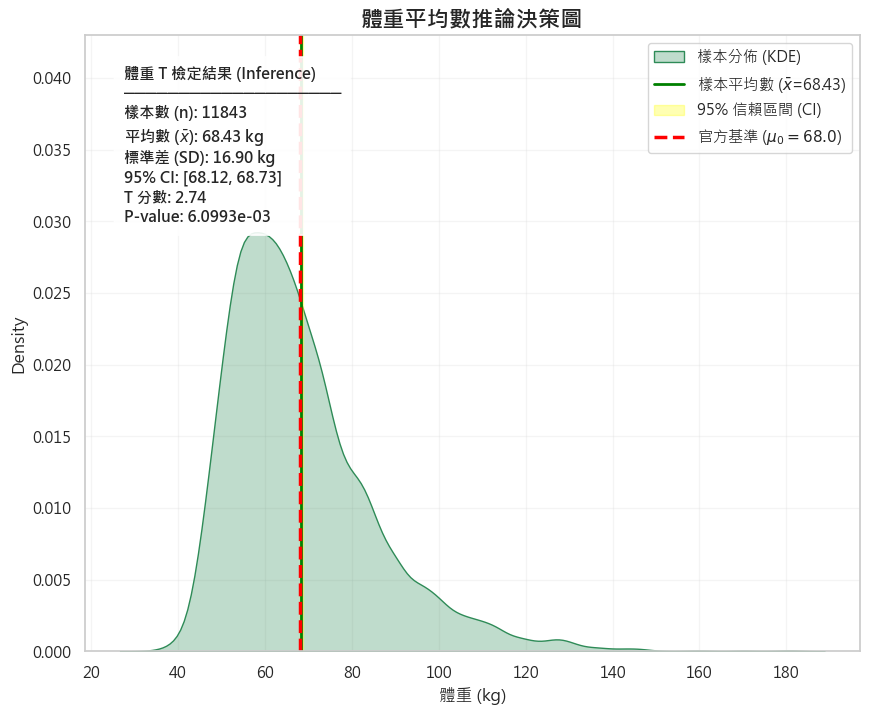

In [35]:

fig_inf, ax = plt.subplots(figsize=(10, 8))
sns.kdeplot(weight_data, fill=True, color="seagreen", alpha=0.3, ax=ax, label='樣本分佈 (KDE)')

#用 fr""
ax.axvline(mean_w, color='green', linestyle='-', linewidth=2, 
           label=fr'樣本平均數 ($\bar{{x}}$={mean_w:.2f})') 

ax.axvspan(ci_w[0], ci_w[1], color='yellow', alpha=0.3, label='95% 信賴區間 (CI)')

#基準值線
ax.axvline(mu0, color='red', linestyle='--', linewidth=2.5, 
           label=fr'官方基準 ($\mu_0={mu0}$)')

#統計資訊方塊使用 fr-string，並處理 \bar
p_text = f"{p_val_w:.4e}" if p_val_w > 0 else "< 2.2e-16"

stats_text = (fr"體重 T 檢定結果 (Inference)" + "\n" +
              r"────────────────────" + "\n" +
              f"樣本數 (n): {n_w}\n" +
              fr"平均數 ($\bar{{x}}$): {mean_w:.2f} kg" + "\n" +
              f"標準差 (SD): {sd_w:.2f} kg\n" +
              f"95% CI: [{ci_w[0]:.2f}, {ci_w[1]:.2f}]\n" +
              f"T 分數: {t_stat:.2f}\n" +
              f"P-value: {p_text}")

# 拉高 Y 軸避免遮擋
ax.set_ylim(0, ax.get_ylim()[1] * 1.4)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.6'),
        verticalalignment='top', fontweight='bold')

ax.set_title('體重平均數推論決策圖', fontsize=16, fontweight='bold')
ax.set_xlabel('體重 (kg)', fontsize=12)
ax.legend(loc='upper right')

plt.grid(axis='both', alpha=0.2)

# 儲存
plt.savefig('../outputs/figures/03_weight_inference_decision_plot.png', dpi=300, bbox_inches='tight')
plt.show()

數值摘要：

酒精使用比例為 45.17% ，信賴區間為 [0.4431, 0.4604]。

平均體重為 68.55 kg ，信賴區間為 [68.26, 68.84]。

信賴區間含意：

比例分析：我們有 95% 的信心，全體美國高中生的飲酒比例落在 0.4431 到 0.4604 之間，此區間完全不包含基準值 0.35。

平均數分析：體重信賴區間不包含 68.0 kg，代表母體平均值有極大機率高於此基準。

假設檢定結論：

由於兩者的 P 值均遠小於 0.05，我們拒絕虛無假設。這代表 2007 年青少年的飲酒比例與平均體重，均顯著不同於老師提供的官方基準值。

一致性觀察：推論結果與 EDA 觀察高度一致。在 EDA 中我們看到飲酒比例接近 45%，且體重分佈受高端離群值影響而略高於基準值 68 kg。


詮釋：體重分析中偵測到 447 筆離群值 ，雖然保留資料是為了生理多樣性，但這些極端高值確實拉高了平均數，若目標群體不含極端過重者，結果可能不同。

In [36]:
# 定義標籤
g_labels = {1: "女性 (Female)", 2: "男性 (Male)"}

for g_val, g_name in g_labels.items():
    # 分群
    drink = df[(df['WhatIsYourSex'] == g_val) & (df['alcohol_binary'] == 1)]['HowMuchDoYouWeighWithoutShoesInKG'].dropna()
    no_drink = df[(df['WhatIsYourSex'] == g_val) & (df['alcohol_binary'] == 0)]['HowMuchDoYouWeighWithoutShoesInKG'].dropna()
    
    # 獨立樣本 T 檢定
    t_res, p_res = stats.ttest_ind(drink, no_drink, equal_var=False)
    
    print(f"【{g_name} 組別檢定結果】")
    print(f"飲酒組平均: {drink.mean():.2f} kg vs. 不飲酒組平均: {no_drink.mean():.2f} kg")
    print(f"P-value: {p_res:.4e}")
    print("-" * 30)

【女性 (Female) 組別檢定結果】
飲酒組平均: 62.15 kg vs. 不飲酒組平均: 62.39 kg
P-value: 5.2048e-01
------------------------------
【男性 (Male) 組別檢定結果】
飲酒組平均: 75.71 kg vs. 不飲酒組平均: 73.70 kg
P-value: 9.1321e-06
------------------------------


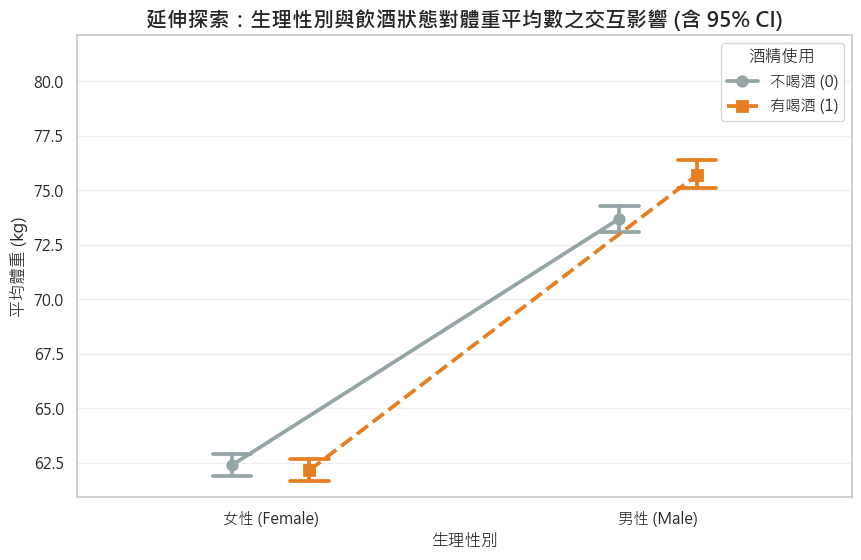

In [37]:
# --- 延伸探索視覺化：生理性別與酒精之體重交互作用圖 ---

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

# 1. 確保繪圖環境與字體設定已載入 (如果你漏了，請補上這幾行)
# plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
# plt.rcParams['axes.unicode_minus'] = False 
# sns.set_theme(style="whitegrid", font='Microsoft JhengHei')

# 2. 準備繪圖數據 (移除缺失值，確保圖表乾淨)
df_plot = df.dropna(subset=['HowMuchDoYouWeighWithoutShoesInKG', 'WhatIsYourSex', 'alcohol_binary'])

# 3. 建立圖表
plt.figure(figsize=(10, 6))

# 使用 pointplot 呈現平均數與信賴區間
# x軸: 性別, y軸: 體重, 顏色: 酒精使用
# join=True 會畫出連線，這有助於觀察「交互作用」
sns.pointplot(x='WhatIsYourSex', y='HowMuchDoYouWeighWithoutShoesInKG', hue='alcohol_binary', 
              data=df_plot, markers=["o", "s"], linestyles=["-", "--"],
              capsize=.1, errorbar=('ci', 95), dodge=0.2,
              palette={0: "#95a5a6", 1: "#e67e22"}) # 灰色=不喝, 橘色=有喝

# 4. 圖表細節優化
plt.xticks([0, 1], ['女性 (Female)', '男性 (Male)'])
plt.title('延伸探索：生理性別與飲酒狀態對體重平均數之交互影響 (含 95% CI)', fontsize=15, fontweight='bold')
plt.ylabel('平均體重 (kg)', fontsize=12)
plt.xlabel('生理性別', fontsize=12)

# 修改圖例
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['不喝酒 (0)', '有喝酒 (1)'], title='酒精使用', loc='best')

# 大幅拉高 Y 軸上限，為統計資訊留空間 (假設最高平均約72kg)
plt.ylim(plt.ylim()[0], plt.ylim()[1] + 5)

plt.grid(axis='y', alpha=0.3)

# 5. 儲存圖表到 outputs
plt.savefig('../outputs/figures/03_extended_exploration_interaction_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
inf_results = [
    # 1. 酒精比例分析
    {
        "Analysis_Type": "Proportion (Alcohol)",
        "Variable": "alcohol_binary",
        "n": n_total,
        "Sample_Stat": round(sample_p, 4),
        "Benchmark": 0.35,
        "Test_Statistic_Z": round(z_stat, 4),
        "P_value": f"{p_val_p:.4e}",
        "CI_Lower": round(ci_low_p, 4),
        "CI_Upper": round(ci_high_p, 4),
        "Result": "Reject H0" if p_val_p < 0.05 else "Fail to Reject H0"
    },
    # 2. 體重平均數分析
    {
        "Analysis_Type": "Mean (Weight)",
        "Variable": "Weight_KG",
        "n": n_w,
        "Sample_Stat": round(mean_w, 2),
        "Benchmark": 68.0,
        "Test_Statistic_T": round(t_stat, 4),
        "P_value": f"{p_val_w:.4e}",
        "CI_Lower": round(ci_w[0], 2),
        "CI_Upper": round(ci_w[1], 2),
        "Result": "Reject H0" if p_val_w < 0.05 else "Fail to Reject H0"
    }
]

# (選修) 如果你也想把「延伸探索：性別差異」存進表裡，可以繼續 append
# 這裡以男性組別為例，你可以比照辦理
# inf_results.append({...})

# 轉換為 DataFrame 並儲存
df_inf_summary = pd.DataFrame(inf_results)

# 確保目錄存在
import os
os.makedirs('../outputs/tables/', exist_ok=True)

# 存檔 (加上 utf-8-sig 確保 Excel 中文不亂碼)
df_inf_summary.to_csv('../outputs/tables/inference_summary_table.csv', index=False, encoding='utf-8-sig')

print("✅ 推論統計摘要表已更新並存檔 (包含 CI 與檢定值)！")
display(df_inf_summary)

✅ 推論統計摘要表已更新並存檔 (包含 CI 與檢定值)！


,Analysis_Type,Variable,n,Sample_Stat,Benchmark,Test_Statistic_Z,P_value,CI_Lower,CI_Upper,Result,Test_Statistic_T
0,Proportion (Alcohol),alcohol_binary,12669,0.4517,0.35,23.0088,3.8041e-117,0.4431,0.4604,Reject H0,NaN
1,Mean (Weight),Weight_KG,11843,68.4300,68.00,NaN,6.0993e-03,68.1200,68.7300,Reject H0,2.7429
